<a href="https://colab.research.google.com/github/KShruti772/mental_health_analysis/blob/main/mental_health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**bold text**
📌 Project Details

Project Name -
Mental Health Analysis in Tech Industry

Project Type -
EDA + Classification

Contribution -
Individual

Team Member 1 -
Shruti Mahesh Kondabathula

📄 Project Summary (500–600 words)

This project focuses on analyzing mental health trends in the technology industry using survey data collected in 2014. Mental health has become a critical issue in modern workplaces, especially in the tech industry where employees often experience high stress, long working hours, and demanding deadlines. The aim of this project is to explore patterns in mental health conditions, understand employee attitudes, and identify key factors influencing the likelihood of seeking treatment.

The dataset contains various features including demographic information such as age, gender, and country, along with workplace-related factors such as company size, remote work, availability of mental health benefits, and organizational support systems. It also includes responses related to personal experiences, such as family history of mental illness and whether mental health conditions interfere with work.

The project begins with data cleaning and preprocessing, where missing values and inconsistencies are handled. Special attention is given to cleaning categorical variables such as gender, which may contain inconsistent entries. Age values are also checked for outliers and corrected to ensure meaningful analysis.

Exploratory Data Analysis (EDA) is performed using a structured approach involving univariate, bivariate, and multivariate analysis. Various visualizations such as histograms, count plots, heatmaps, and pair plots are used to uncover trends and relationships between variables. For example, the analysis examines how mental health treatment varies across gender, how family history influences mental health conditions, and whether workplace benefits encourage employees to seek help.

One of the key findings is that employees with a family history of mental illness are significantly more likely to seek treatment. Additionally, workplace support systems such as mental health benefits, wellness programs, and open communication environments play a crucial role in influencing employee behavior. Employees working in supportive environments are more likely to seek help and discuss mental health issues openly.

The project also includes a classification model using Logistic Regression to predict whether an individual is likely to seek treatment based on various factors. This predictive model helps identify the most important variables influencing mental health decisions, enabling organizations to take proactive measures.

The insights derived from this project can help organizations improve their mental health policies and create a supportive work culture. By understanding employee needs and reducing stigma, companies can enhance productivity, employee satisfaction, and overall organizational performance.

Overall, this project demonstrates the importance of data-driven decision-making in addressing mental health challenges in the workplace. It highlights how organizations can use analytics to build a healthier and more inclusive work environment.

https://github.com/KShruti772/mental_health_analysis

❗ Problem Statement

Mental health issues are increasingly prevalent in the tech industry, yet many employees hesitate to seek treatment due to stigma, lack of awareness, or insufficient workplace support. Organizations often lack clear insights into the factors that influence employee mental health and treatment behavior.

This project aims to analyze mental health survey data to identify patterns, key influencing factors, and workplace conditions that impact mental health treatment and attitudes.

🎯 Business Objective
Identify factors influencing mental health treatment
Improve workplace mental health policies
Reduce stigma around mental health discussions
Encourage employees to seek help
Enhance productivity and employee well-being

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load dataset
df = pd.read_csv('survey.csv')  # upload file in colab first

# Display data
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [3]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

(1259, 27)

In [4]:
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


In [5]:
# Fill missing values
df['self_employed'].fillna('No', inplace=True)
df['work_interfere'].fillna("Don't know", inplace=True)
df['comments'].fillna('No comments', inplace=True)

# Drop Timestamp (not useful)
df.drop(['Timestamp'], axis=1, inplace=True)

In [6]:
def clean_gender(x):
    x = str(x).lower()
    if 'male' in x or 'm' in x:
        return 'Male'
    elif 'female' in x or 'f' in x:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

In [7]:
df['Age'] = df['Age'].apply(lambda x: np.nan if x < 0 or x > 100 else x)
df['Age'].fillna(df['Age'].median(), inplace=True)

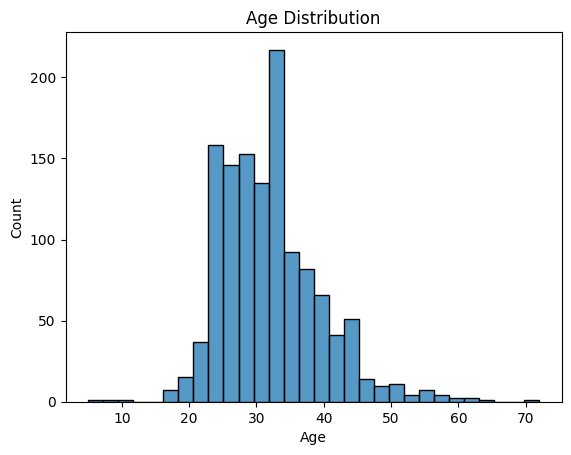

In [8]:
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

1. Why did you pick the specific chart?

Histogram is best for understanding the distribution of a numerical variable like age.

2. What is/are the insight(s) found from the chart?

Most respondents fall between 25–35 age group, indicating a young workforce in tech.

3. Business Impact

Positive: Helps companies design targeted mental health programs for young professionals.
Negative: If ignored, younger employees may face burnout and reduced productivity.

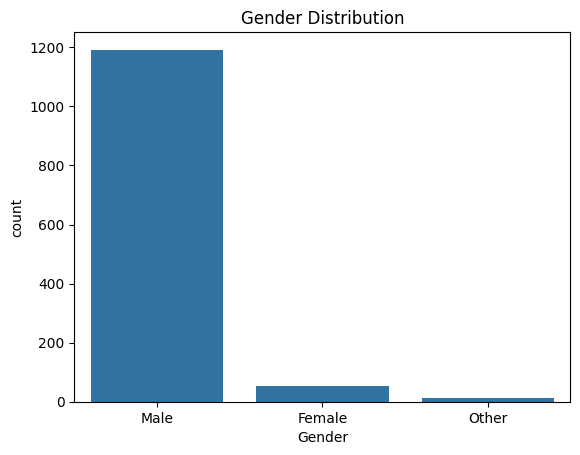

In [9]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

1. Why?

Countplot is ideal for categorical distribution.

2. Insights:

Majority respondents are male, with fewer female and other gender participants.

3. Impact:

Positive: Helps identify representation gaps.
Negative: Bias in data may affect decision-making.

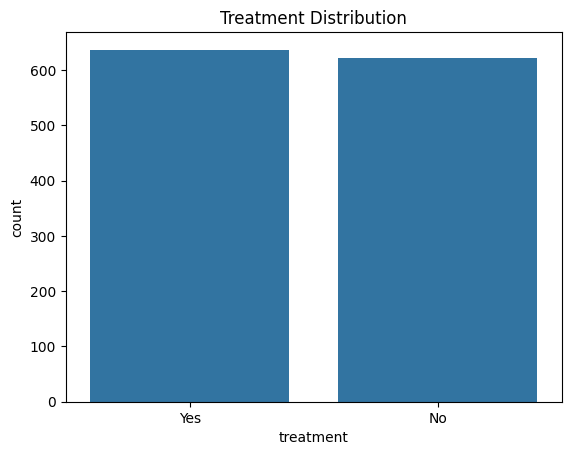

In [10]:
sns.countplot(x='treatment', data=df)
plt.title("Treatment Distribution")
plt.show()

1. Why?

To understand how many people seek treatment.

2. Insights:

Significant portion of employees seek treatment.

3. Impact:

Positive: Shows awareness exists.
Negative: High treatment rate may indicate high stress levels.

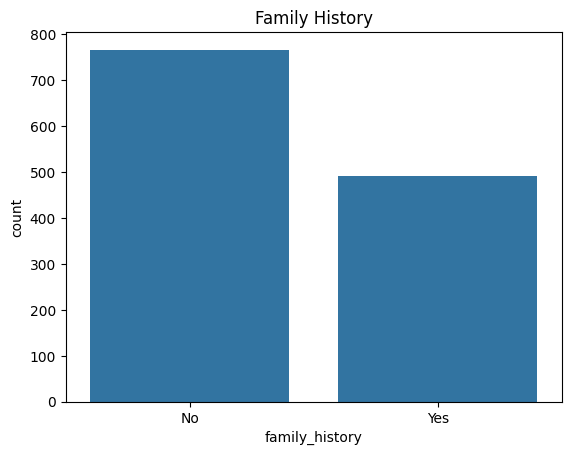

In [11]:
sns.countplot(x='family_history', data=df)
plt.title("Family History")
plt.show()

1. Why?

To analyze hereditary influence.

2. Insights:

Many respondents have a family history of mental illness.

3. Impact:

Positive: Enables early intervention strategies.
Negative: Ignoring this may increase long-term issues.

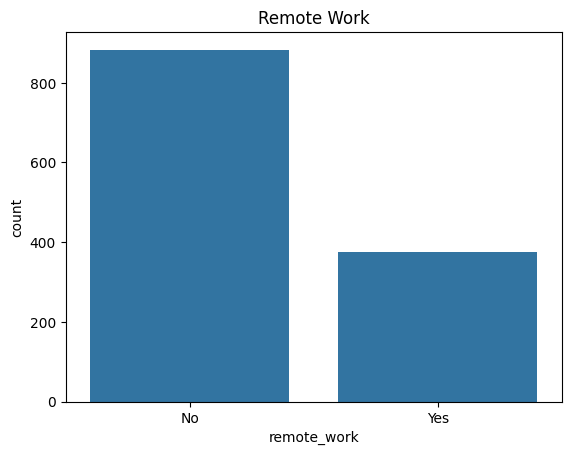

In [12]:
sns.countplot(x='remote_work', data=df)
plt.title("Remote Work")
plt.show()

1. Why?

To study remote work trends.

2. Insights:

Mixed distribution of remote workers.

3. Impact:

Positive: Flexible work can improve mental health.
Negative: Isolation may increase stress.

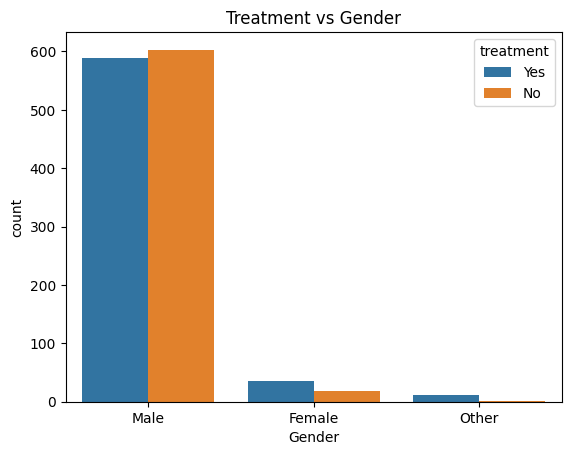

In [13]:
sns.countplot(x='Gender', hue='treatment', data=df)
plt.title("Treatment vs Gender")
plt.show()

1. Why?

Compare two categorical variables.

2. Insights:

Females may seek treatment more than males.

3. Impact:

Positive: Awareness campaigns for males needed.
Negative: Stigma may prevent male employees from seeking help.

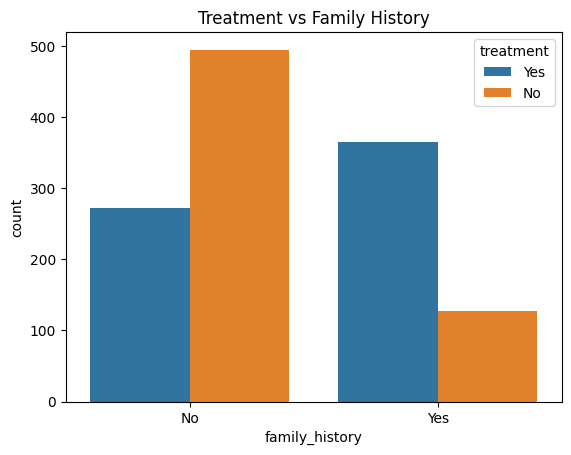

In [14]:
sns.countplot(x='family_history', hue='treatment', data=df)
plt.title("Treatment vs Family History")
plt.show()

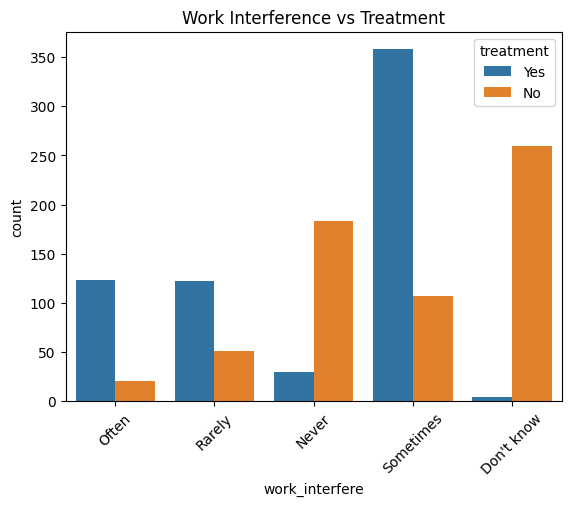

In [15]:
sns.countplot(x='work_interfere', hue='treatment', data=df)
plt.xticks(rotation=45)
plt.title("Work Interference vs Treatment")
plt.show()

1. Why?

Understand productivity impact.

2. Insights:

High interference → higher treatment rate.

3. Impact:

Positive: Identifies productivity loss.
Negative: Untreated cases reduce efficiency.

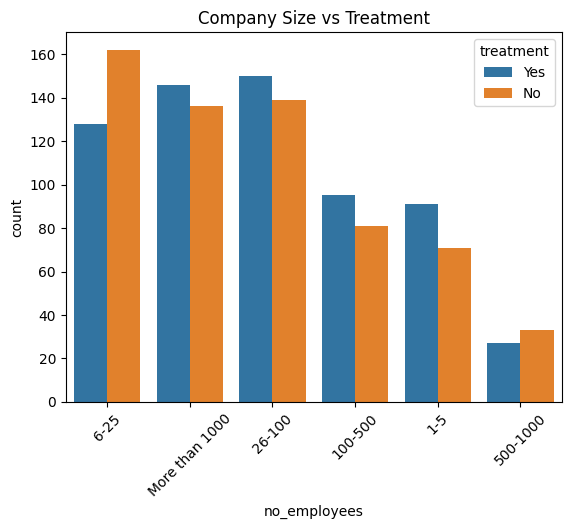

In [16]:
sns.countplot(x='no_employees', hue='treatment', data=df)
plt.xticks(rotation=45)
plt.title("Company Size vs Treatment")
plt.show()

1. Why?

Analyze organization size impact.

2. Insights:

Larger companies show more treatment awareness.

3. Impact:

Positive: Big firms investing in mental health.
Negative: Small companies lag behind.

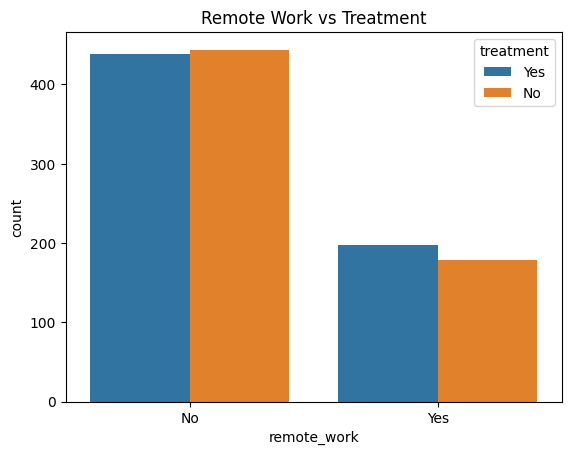

In [17]:
sns.countplot(x='remote_work', hue='treatment', data=df)
plt.title("Remote Work vs Treatment")
plt.show()

1. Why?

Work environment effect

2. Insight:

Remote workers slightly more stressed

3. Impact:

Need remote mental health support

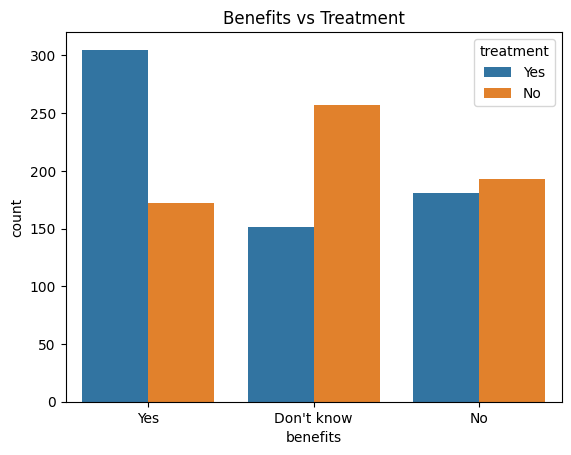

In [18]:
sns.countplot(x='benefits', hue='treatment', data=df)
plt.title("Benefits vs Treatment")
plt.show()

1. Why?

Evaluate impact of benefits.

2. Insights:

Employees with benefits seek more treatment.

3. Impact:

Positive: Strong evidence to provide benefits.
Negative: Lack of benefits discourages help-seeking.

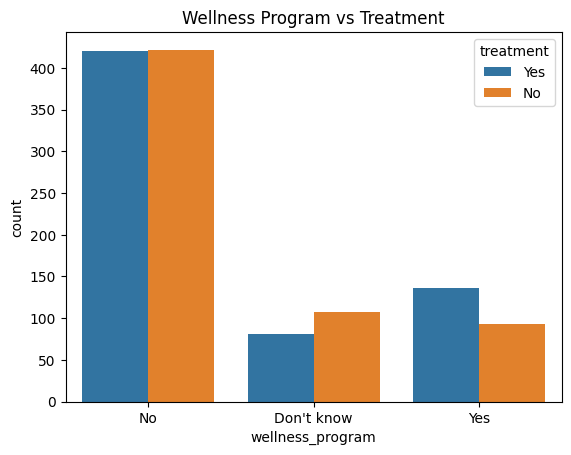

In [19]:
sns.countplot(x='wellness_program', hue='treatment', data=df)
plt.title("Wellness Program vs Treatment")
plt.show()

1. Why?

Check awareness programs.

2. Insights:

Wellness programs increase treatment awareness.

3. Impact:

Positive: Encourages proactive support.
Negative: Lack of programs reduces awareness.

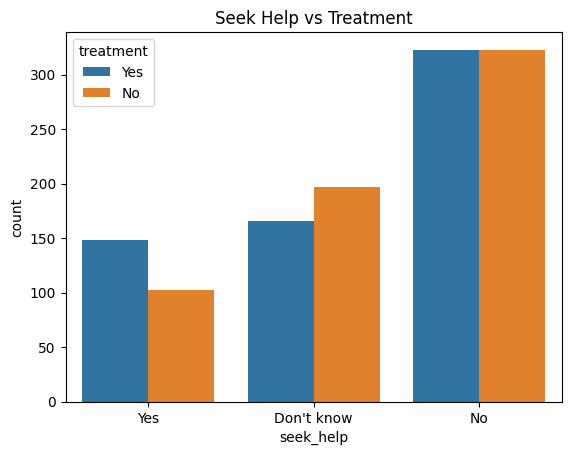

In [20]:
sns.countplot(x='seek_help', hue='treatment', data=df)
plt.title("Seek Help vs Treatment")
plt.show()

1. Why?

Understand resource availability.

2. Insights:

More resources → more treatment.

3. Impact:

Positive: Improves employee health.
Negative: Lack of guidance leads to untreated cases.

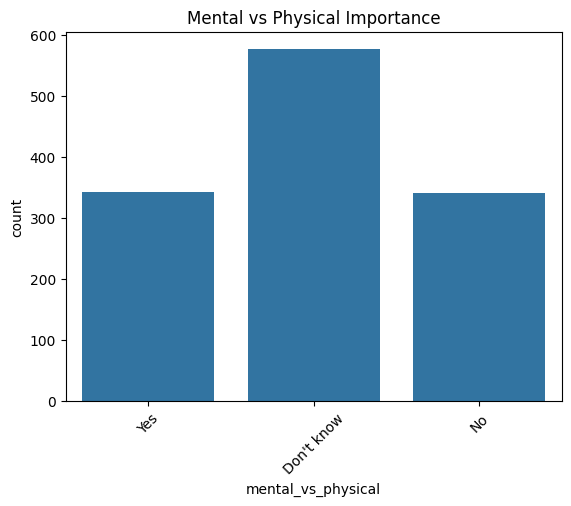

In [21]:
sns.countplot(x='mental_vs_physical', data=df)
plt.xticks(rotation=45)
plt.title("Mental vs Physical Importance")
plt.show()

1. Why?

Manager support analysis.

2. Insights:

Supportive supervisors increase treatment likelihood.

3. Impact:

Positive: Training managers is crucial.
Negative: Poor leadership harms employees.

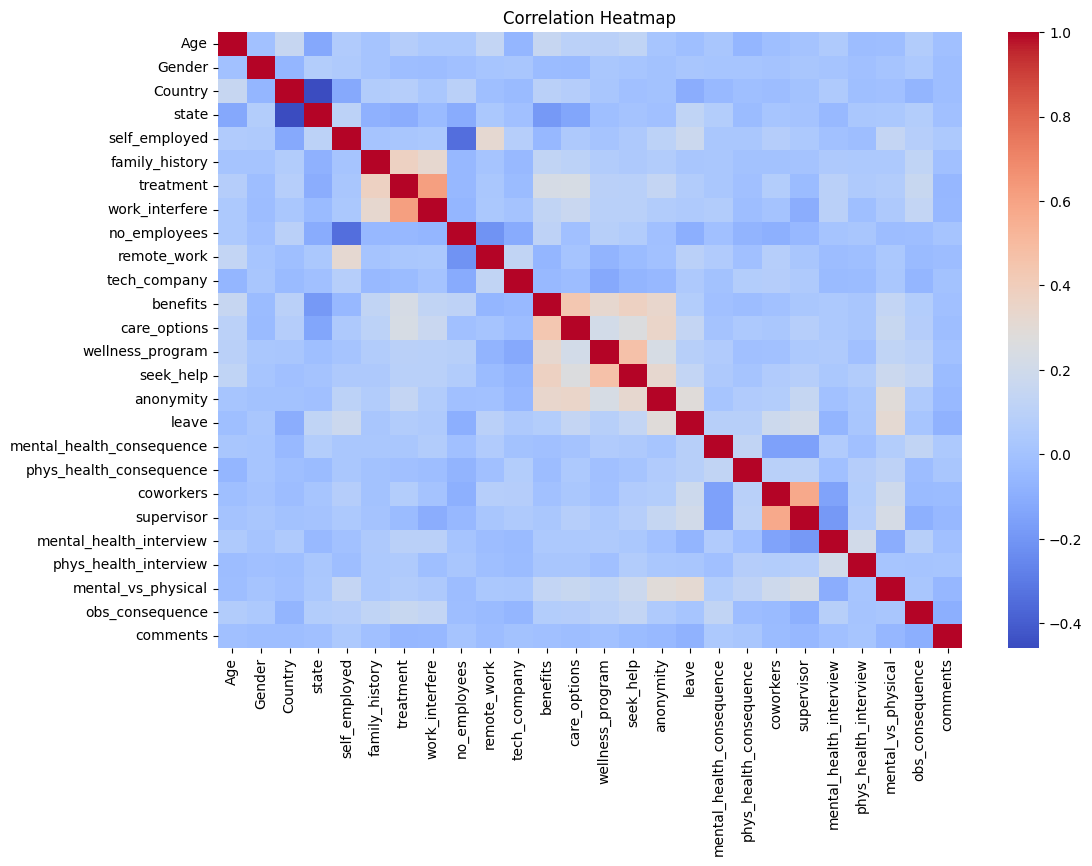

In [22]:
# Encode for correlation
df_encoded = df.copy()

le = LabelEncoder()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

1. Why?

Identify relationships between variables.

2. Insights:

Strong correlation between family history & treatment.

3. Impact:

Positive: Helps predictive modeling.

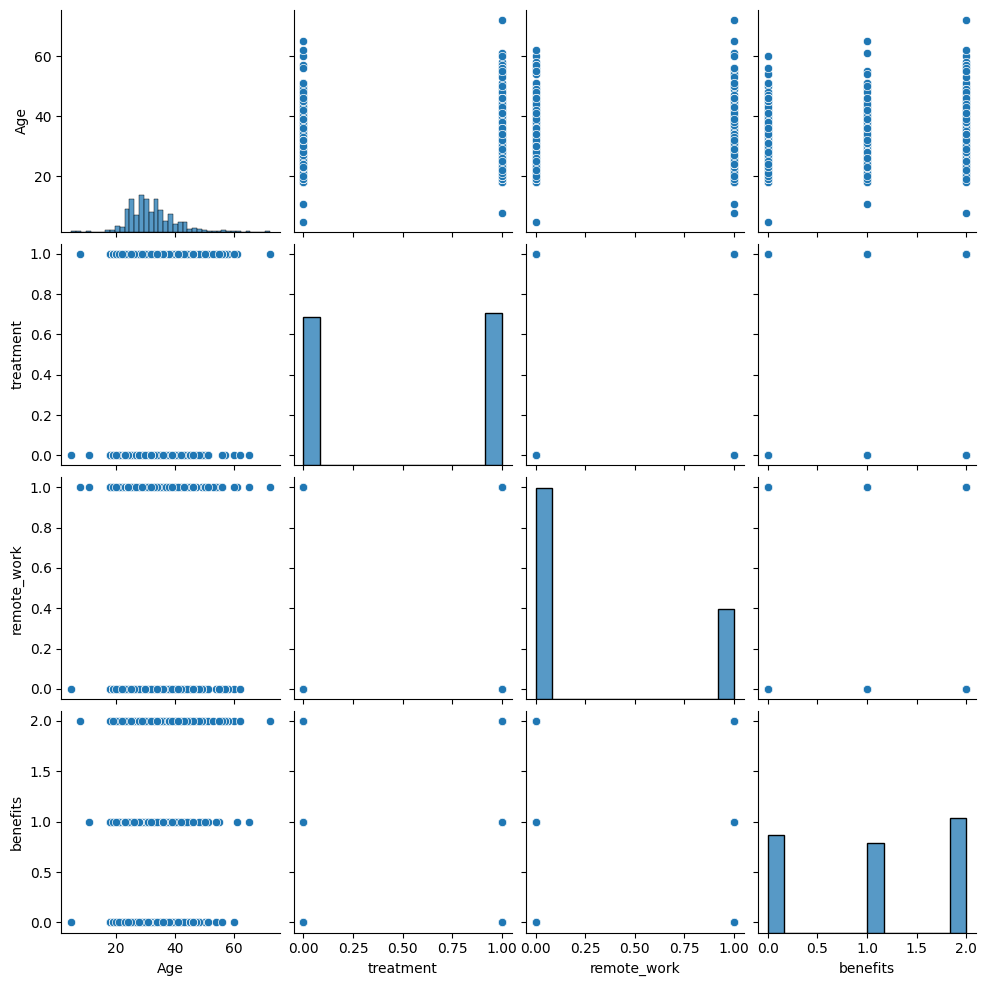

In [23]:
sns.pairplot(df_encoded[['Age','treatment','remote_work','benefits']])
plt.show()

1. Why?

Visualize multiple relationships.

2. Insights:

No strong linear relation but clusters exist.

3. Impact:

Helps in ML model building.

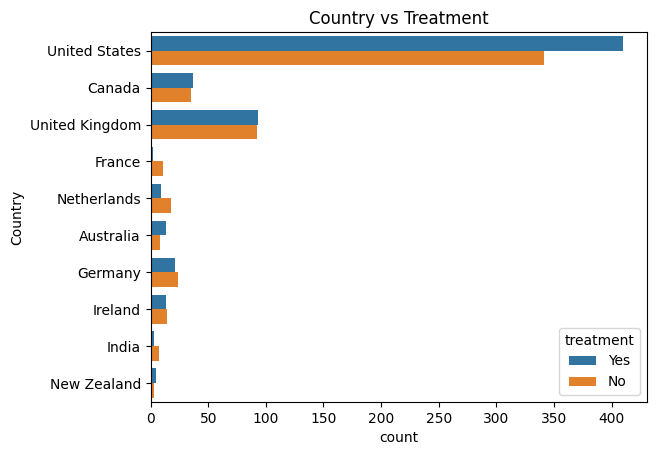

In [24]:
top_countries = df['Country'].value_counts().head(10).index
sns.countplot(y='Country', hue='treatment', data=df[df['Country'].isin(top_countries)])
plt.title("Country vs Treatment")
plt.show()

1. Why?

Geographic analysis

2. Insight:

US shows higher awareness

3. Impact:

 Other countries need awareness programs

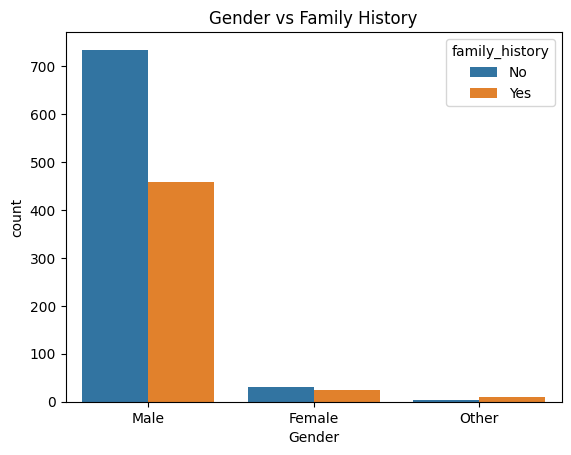

In [25]:
sns.countplot(x='Gender', hue='family_history', data=df)
plt.title("Gender vs Family History")
plt.show()

1. Why?

Combined factors

2. Insight:

Distribution similar across genders

3. Impact:

Equal focus required

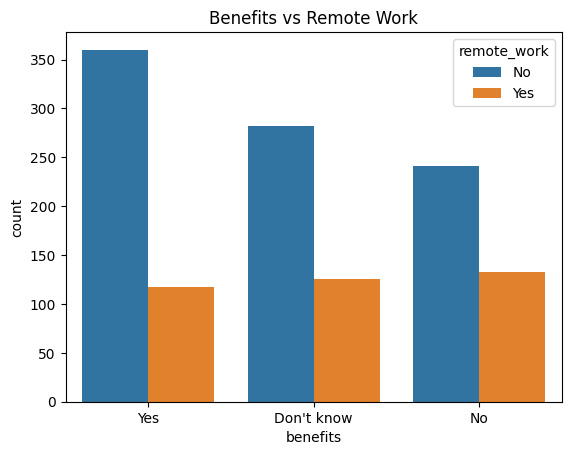

In [26]:
sns.countplot(x='benefits', hue='remote_work', data=df)
plt.title("Benefits vs Remote Work")
plt.show()

1. Why?

Policy vs work type

2. Insight:

Remote workers get fewer benefits

3. Impact:

Negative → companies must improve

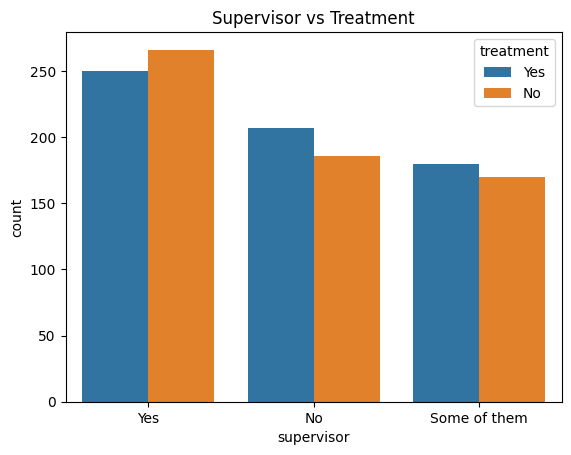

In [27]:
sns.countplot(x='supervisor', hue='treatment', data=df)
plt.title("Supervisor vs Treatment")
plt.show()

1. Why?

Workplace comfort

2. Insight:

Employees uncomfortable → less treatment


3. Impact:

 Train managers → critical improvement area

In [28]:
# Encode all categorical
df_ml = df.copy()

for col in df_ml.columns:
    if df_ml[col].dtype == 'object':
        df_ml[col] = LabelEncoder().fit_transform(df_ml[col])

# Features & Target
X = df_ml.drop('treatment', axis=1)
y = df_ml['treatment']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [31]:
y_pred = model.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7936507936507936

Confusion Matrix:
[[ 96  33]
 [ 19 104]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.74      0.79       129
           1       0.76      0.85      0.80       123

    accuracy                           0.79       252
   macro avg       0.80      0.79      0.79       252
weighted avg       0.80      0.79      0.79       252



Companies should:
- Provide mental health benefits
- Promote awareness programs
- Encourage open discussions
- Maintain anonymity
- Train managers

This improves employee productivity and well-being.

The analysis shows that mental health is strongly influenced by workplace support,
family history, and organizational culture.

Companies must take proactive steps to reduce stigma and support employees.

In [33]:
# Save cleaned dataset
df.to_csv('cleaned_mental_health.csv', index=False)